# Imports

In [1]:
import numpy as np
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import PIL
import PIL.Image
import os
import pathlib
import math
print(tf.__version__)

2025-04-20 12:43:05.682561: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745152985.876493      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745152985.933957      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


2.18.0


In [2]:
# import kagglehub


# # Download latest version
# path = kagglehub.dataset_download("nafin59/monkeypox-skin-lesion-dataset")

# print("Path to dataset files:", path)
# # path = kagglehub.dataset_download("dipuiucse/monkeypoxskinimagedataset")


# # files = os.listdir('../input/monkeypox-skin-lesion-dataset/Fold1/Fold1/Fold1/Test')
# # files = os.listdir('../input/monkeypoxskinimagedataset/Monkeypox Skin Image Dataset')


**Hyper-parameters**

In [3]:
import os

print(os.listdir("/kaggle/input/"))

['mpox-skin-lesion-dataset-version-20-msld-v20', 'msld-binary']


In [4]:
batch_size = 32
img_height = 224
img_width = 224
lr_rate = 1e-3
lr_mode = 'cos'
epochs = 30
data_dir = pathlib.Path('/kaggle/input/msld-binary/Augmented Images/Augmented Images').with_suffix('')

# Data preprocessing

In [5]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

class_names = train_ds.class_names
print(class_names)

Found 3192 files belonging to 2 classes.
Using 2554 files for training.


I0000 00:00:1745153000.857271      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 3192 files belonging to 2 classes.
Using 638 files for validation.
['Monkeypox_augmented', 'Others_augmented']


In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [ ]:
for image_batch, labels_batch in train_ds:
    print(image_batch.shape)
    print(labels_batch.shape)
    break

(32, 224, 224, 3)
(32,)


## Autotone

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## Normalization

In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixel values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))

0.03529412 0.9725491


In [10]:
base_model = keras.applications.ResNet50(
    weights='imagenet',  # Load weights pre-trained on ImageNet.
    input_shape=(img_width, img_height, 3),
    include_top=False)  # Do not include the ImageNet classifier at the top.

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [11]:
base_model.trainable = False

In [12]:
inputs = keras.Input(shape=(img_width, img_height, 3))
x = base_model(inputs, training=False)
x = keras.layers.Conv2D(512, 3, padding='same', activation='relu')(x)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(256, activation='relu')(x)
outputs = keras.layers.Dense(6)(x)

model = keras.Model(inputs, outputs)

In [13]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 7, 7, 512)           │       9,437,696 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │           1,542 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 33,158,278 (126.49 MB)

 Trainable params: 9,570,566 (36.51 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## LR Schedule

In [14]:
def get_lr_callback(batch_size=8, mode='cos', epochs=10, plot=False):
    lr_start, lr_max, lr_min = 5e-5, 6e-6 * batch_size, 1e-5
    lr_ramp_ep, lr_sus_ep, lr_decay = 3, 0, 0.75

    def lrfn(epoch):  # Learning rate update function
        if epoch < lr_ramp_ep: lr = (lr_max - lr_start) / lr_ramp_ep * epoch + lr_start
        elif epoch < lr_ramp_ep + lr_sus_ep: lr = lr_max
        elif mode == 'exp': lr = (lr_max - lr_min) * lr_decay**(epoch - lr_ramp_ep - lr_sus_ep) + lr_min
        elif mode == 'step': lr = lr_max * lr_decay**((epoch - lr_ramp_ep - lr_sus_ep) // 2)
        elif mode == 'cos':
            decay_total_epochs, decay_epoch_index = epochs - lr_ramp_ep - lr_sus_ep + 3, epoch - lr_ramp_ep - lr_sus_ep
            phase = math.pi * decay_epoch_index / decay_total_epochs
            lr = (lr_max - lr_min) * 0.5 * (1 + math.cos(phase)) + lr_min
        return lr

    if plot:  # Plot lr curve if plot is True
        plt.figure(figsize=(10, 5))
        plt.plot(np.arange(epochs), [lrfn(epoch) for epoch in np.arange(epochs)], marker='o')
        plt.xlabel('epoch'); plt.ylabel('lr')
        plt.title('LR Scheduler')
        plt.show()

    return keras.callbacks.LearningRateScheduler(lrfn, verbose=False)  # Create lr callback

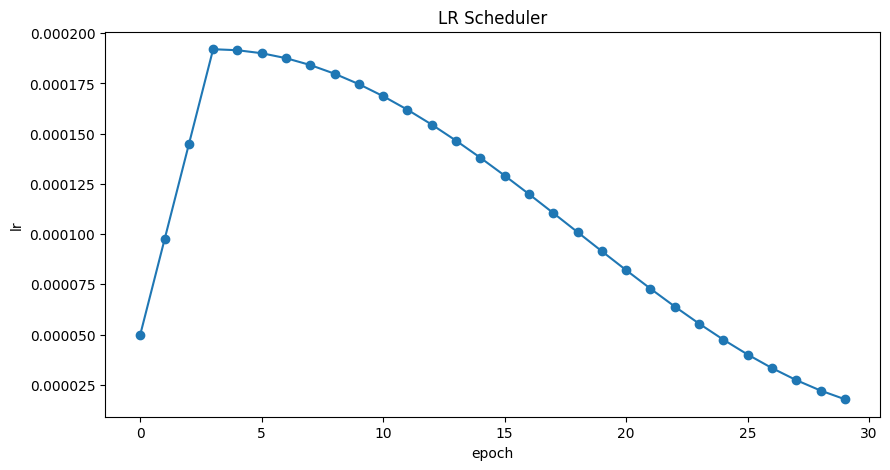

In [15]:
lr_cb = get_lr_callback(batch_size, mode=lr_mode, plot=True, epochs=epochs)

In [16]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr_rate),
              loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [17]:
history = model.fit(
    train_ds,
    epochs=epochs,
    callbacks=[early_stopping, lr_cb],
    validation_data=train_ds)

Epoch 1/30


I0000 00:00:1745153022.187220      96 service.cc:148] XLA service 0x7a39ec001ee0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745153022.188058      96 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1745153023.590040      96 cuda_dnn.cc:529] Loaded cuDNN version 90300


 3/80 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.4878 - loss: 1.5549 

I0000 00:00:1745153028.280205      96 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


80/80 ━━━━━━━━━━━━━━━━━━━━ 37s 256ms/step - accuracy: 0.7583 - loss: 0.5851 - val_accuracy: 0.8716 - val_loss: 0.2731 - learning_rate: 5.0000e-05
Epoch 2/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 106ms/step - accuracy: 0.9154 - loss: 0.2151 - val_accuracy: 0.9002 - val_loss: 0.2161 - learning_rate: 9.7333e-05
Epoch 3/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 106ms/step - accuracy: 0.9324 - loss: 0.1842 - val_accuracy: 0.9565 - val_loss: 0.1051 - learning_rate: 1.4467e-04
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 106ms/step - accuracy: 0.9469 - loss: 0.1428 - val_accuracy: 0.9197 - val_loss: 0.1815 - learning_rate: 1.9200e-04
Epoch 5/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 106ms/step - accuracy: 0.9601 - loss: 0.0977 - val_accuracy: 0.9722 - val_loss: 0.0641 - learning_rate: 1.9150e-04
Epoch 6/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 106ms/step - accuracy: 0.9735 - loss: 0.0751 - val_accuracy: 0.9471 - val_loss: 0.1087 - learning_rate: 1.9001e-04
Epoch 7/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 106ms/step - accuracy: 0.9836 - l

# Evaluation

# Plot training results

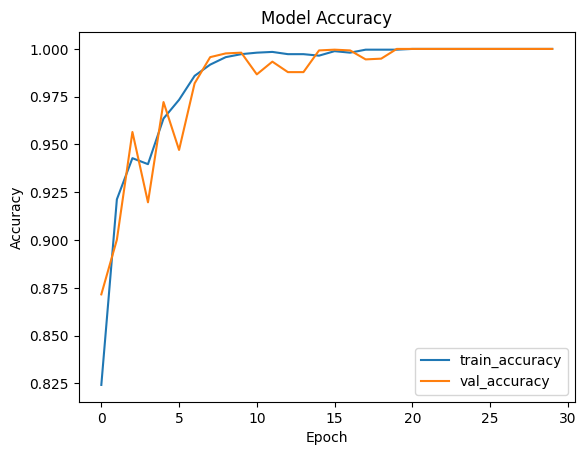

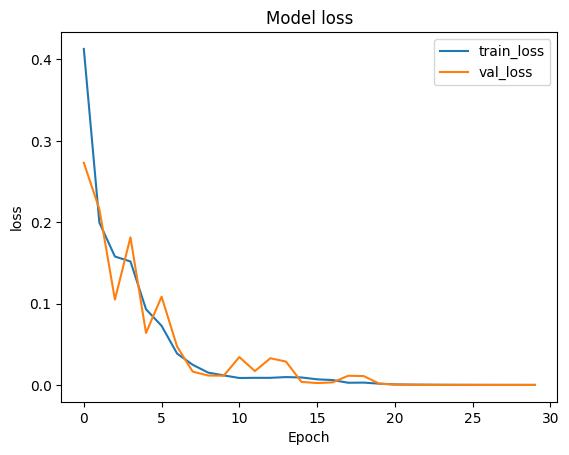

In [18]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['train_accuracy', 'val_accuracy'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('Epoch')
plt.legend(['train_loss', 'val_loss'])
plt.show()

## Testing

### Test 1

In [19]:
test_data_dir = '/kaggle/input/msld-binary/Fold1/Fold1/Fold1/Val'
test_ds = tf.keras.utils.image_dataset_from_directory(
  test_data_dir,
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

model.evaluate(test_ds)

Found 420 files belonging to 2 classes.
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 237ms/step - accuracy: 0.9905 - loss: 0.0314


[0.04445458948612213, 0.9857142567634583]

### Test 2

In [20]:
test_data_dir = '/kaggle/input/msld-binary/Fold1/Fold1/Fold1/Test'
test_ds = tf.keras.utils.image_dataset_from_directory(
  test_data_dir,
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

model.evaluate(test_ds)

Found 45 files belonging to 2 classes.
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 1.0000 - loss: 3.3200e-06 


[3.1788626984052826e-06, 1.0]

## Test 3

In [21]:
# test_data_dir = '/kaggle/input/Original Images/Original Images/FOLDS/fold2/Valid'
# test_ds = tf.keras.utils.image_dataset_from_directory(
#   test_data_dir,
#   seed=123,
#   image_size=(img_height, img_width),
#   batch_size=batch_size)

# test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# model.evaluate(test_ds)

## Test 4

In [22]:
# test_data_dir = '/kaggle/input/Original Images/Original Images/FOLDS/fold3/Valid'
# test_ds = tf.keras.utils.image_dataset_from_directory(
#   test_data_dir,
#   seed=123,
#   image_size=(img_height, img_width),
#   batch_size=batch_size)

# test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# model.evaluate(test_ds)

## Test 5

In [23]:
# test_data_dir = '/kaggle/input/Original Images/Original Images/FOLDS/fold4/Valid'
# test_ds = tf.keras.utils.image_dataset_from_directory(
#   test_data_dir,
#   seed=123,
#   image_size=(img_height, img_width),
#   batch_size=batch_size)

# test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# model.evaluate(test_ds)

## Test 5

In [24]:
# test_data_dir = '/kaggle/input/Original Images/Original Images/FOLDS/fold5/Valid'
# test_ds = tf.keras.utils.image_dataset_from_directory(
#   test_data_dir,
#   seed=123,
#   image_size=(img_height, img_width),
#   batch_size=batch_size)

# test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# model.evaluate(test_ds)

# Export and save the model

In [25]:
#Save the entire model
model.save('SkinNet.keras')
#Save training checkpoint
!mkdir checkpoints
model.save_weights('checkpoints/SkinNet.weights.h5')
#Export the model for inference
model.export('export/exported_SkinNet_model')

Saved artifact at 'export/exported_SkinNet_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_175')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  134392440815056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134392440812368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134392440814672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134392440814096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134392440811984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134392440811216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134391878501008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134391878503312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134391878504272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134391878503696: TensorSpec(shape=(), dtype=tf.resource, name=None)

# Get in touch
#### Reach me out at:
- Email: [aalrefaei93@gmail.com](mailto:aalrefaei93@gmail.com)
- X: [@guy_997](https://twitter.com/guy_997)
- Instagram: [@guy_997](https://www.instagram.com/guy_997/) 
- Github: [@guy-977](https://github.com/guy-977)
- HuggingFace: [@ahmed-ai](https://huggingface.co/ahmed-ai)
- Telegram: [@guy_997](https://t.me/guy_997)
- Discord: @ahmed.gov